# Mutual proportion/global symmetry analysis for Run 32 MO vs SO 

In [1]:
#using tianyi enviroment Python 3.11.3

import numpy as np
import pickle as pkl
import pandas as pd
from pprint import pprint
import os
import matplotlib
import matplotlib.pyplot as plt
import glob
import igraph as ig
plt.ion()

In [2]:

# Path of source .pkl result files
path_source_files = '/cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/'

# Get a list of files that we'll analyze (pkl files in the source directory or its subdirectories)
filenames = glob.glob(f'{path_source_files}/**/*.pkl', recursive=True)
n_chars = len(path_source_files)
filenames = [f[n_chars:] for f in filenames]
filenames.sort()
filenames.reverse()

print(f'Found {len(filenames)} pkl files to process.')


Found 16 pkl files to process.


In [3]:
filenames = [os.path.join(path_source_files, filename.lstrip('/')) for filename in filenames]

In [4]:
def filter_matrix_TC(data, well, win):

    # Extract necessary data from the loaded data structure
    adj_matrix = data[well][win]['adj_matrix_predicted']
    votes = data[well][win]['votes']  # This variable is loaded but not used in the snippet you provided
    corr_peaks = data[well][win]['corr_peaks']
    fs = data['config']['data']['fs']  # Sampling frequency

    # Initialize a matrix to track synchronization based on correlation peaks
    synced_matrix = np.full(adj_matrix.shape, False)
    for key in corr_peaks.keys():
        if np.all(np.abs(np.array(corr_peaks[key]['delays'])) < 1/fs):
            synced_matrix[key[0], key[1]] = True
            synced_matrix[key[1], key[0]] = True

    # Create the filtered matrix as per the given logic
    filtered_matrix = np.logical_and(adj_matrix, np.logical_not(synced_matrix))

    return filtered_matrix


def get_directed_clique_density_stats(adj):
    """
    Calculates Core-Periphery statistics for a DIRECTED graph, including
    densities and reciprocity (rho) for the whole graph and per block.
    """
    # Ensure binary directed adjacency
    adj_bin = (adj > 0).astype(int)
    
    # Create Directed Graph
    g = ig.Graph.Adjacency(adj_bin.tolist(), mode="directed")
    
    # Coreness (mode='all' for structural coreness)
    kc = np.array(g.coreness(mode="all"))
    max_k = np.max(kc) if len(kc) > 0 else 0
    
    core_indices = np.where(kc == max_k)[0]
    all_indices = np.arange(adj.shape[0])
    periph_indices = np.setdiff1d(all_indices, core_indices)
    
    n_c, n_p = len(core_indices), len(periph_indices)
    
    # --- Extract Sub-matrices ---
    Acc = adj[np.ix_(core_indices, core_indices)] if n_c > 0 else np.array([])
    App = adj[np.ix_(periph_indices, periph_indices)] if n_p > 0 else np.array([])
    Acp = adj[np.ix_(core_indices, periph_indices)] if (n_c > 0 and n_p > 0) else np.array([])
    Apc = adj[np.ix_(periph_indices, core_indices)] if (n_c > 0 and n_p > 0) else np.array([])

    # --- Edge Counts ---
    edges_CC = Acc.sum() if Acc.size > 0 else 0
    edges_PP = App.sum() if App.size > 0 else 0
    edges_CP = Acp.sum() if Acp.size > 0 else 0
    edges_PC = Apc.sum() if Apc.size > 0 else 0

    # --- Densities ---
    max_CC = n_c * (n_c - 1)
    max_PP = n_p * (n_p - 1)
    max_CP = n_c * n_p
    max_PC = n_p * n_c
    
    dens_CC = edges_CC / max_CC if max_CC > 0 else 0
    dens_PP = edges_PP / max_PP if max_PP > 0 else 0
    dens_CP = edges_CP / max_CP if max_CP > 0 else 0
    dens_PC = edges_PC / max_PC if max_PC > 0 else 0

    # --- Reciprocity ---
    num_rho_global = np.sum(adj * adj.T)
    den_rho_global = np.sum(adj)
    rho_global = num_rho_global / den_rho_global if den_rho_global > 0 else 0

    rho_CC = 0
    if Acc.size > 0 and edges_CC > 0:
        rho_CC = np.sum(Acc * Acc.T) / edges_CC
        
    rho_PP = 0
    if App.size > 0 and edges_PP > 0:
        rho_PP = np.sum(App * App.T) / edges_PP

    rho_inter = 0
    edges_inter = edges_CP + edges_PC
    if Acp.size > 0 and edges_inter > 0:
        mutual_inter_matrix = Acp * Apc.T 
        rho_inter = (2 * np.sum(mutual_inter_matrix)) / edges_inter

    return {
        'dens_CC': dens_CC, 'dens_CP': dens_CP,
        'dens_PC': dens_PC, 'dens_PP': dens_PP,
        'n_core': n_c, 'n_periph': n_p,
        'rho_global': rho_global,
        'rho_CC': rho_CC,
        'rho_PP': rho_PP,
        'rho_CP': rho_inter,
        'rho_PC': rho_inter
    }

In [5]:
import matplotlib.pyplot as plt
import re

# Stage mapping
stage_map = {
    # Activity Scan
    '000386': "Stage 0", '000384': "Stage 0",
    
    # Baseline (Pre-Stim)
    '000387': "Stage 1", '000385': "Stage 1",  # Baseline #1
    '000395': "Stage 2", '000390': "Stage 2",  # Baseline #2
    
    # Stimulation #1 (Random)
    '000396': "Stage 3", '000391': "Stage 3",  # During Stim
    '000397': "Stage 4", '000392': "Stage 4",  # Post Stim
    
    # Stimulation #2 (Single Region)
    '000398': "Stage 5", '000393': "Stage 5",  # During Stim
    '000399': "Stage 6", '000394': "Stage 6"   # Post Stim
}


filtered_filenames = [f for f in filenames if 'M07359' in f or 'M08438' in f]

# Extract stage information from filenames
def extract_stage_and_chip(filename):
    # Extract chip ID (M07359 or M08438)
    chip_match = re.search(r'(M\d{5})', filename)
    chip_id = chip_match.group(1) if chip_match else None
    
    # Extract recording number (e.g., 000384, 000392) - look for it after a known folder structure
    # It should be a 6-digit number starting with 000
    rec_match = re.search(r'/(000\d{3})/', filename)
    rec_num = rec_match.group(1) if rec_match else None
    
    stage = stage_map.get(rec_num, None)
    
    return chip_id, stage, rec_num


def get_clique_density_stats(adj):
    """
    Calculates Core-Periphery statistics based on max k-core.
    """
    # 1. Convert to igraph for coreness calculation
    # Ensure binary/symmetric
    adj_bin = (adj > 0).astype(int)
    g = ig.Graph.Adjacency(adj_bin.tolist(), mode="undirected")
    
    # 2. Identify Core Nodes (Max Coreness)
    # coreness() returns the k-core number for each vertex
    kc = np.array(g.coreness())
    max_k = np.max(kc) if len(kc) > 0 else 0
    
    # Indices in Python are 0-based
    core_indices = np.where(kc == max_k)[0]
    all_indices = np.arange(adj.shape[0])
    periph_indices = np.setdiff1d(all_indices, core_indices)
    
    n_c = len(core_indices)
    n_p = len(periph_indices)
    
    # 3. Calculate Edges (using numpy slicing)
    # CC (internal core edges) -> sum / 2 for undirected
    if n_c > 1:
        edges_CC = adj[np.ix_(core_indices, core_indices)].sum() / 2
    else:
        edges_CC = 0
        
    # PP (internal periphery edges) -> sum / 2
    if n_p > 1:
        edges_PP = adj[np.ix_(periph_indices, periph_indices)].sum() / 2
    else:
        edges_PP = 0
        
    # CP (edges between core and periphery) -> sum (no division)
    if n_c > 0 and n_p > 0:
        edges_CP = adj[np.ix_(core_indices, periph_indices)].sum()
    else:
        edges_CP = 0
        
    # 4. Calculate Max Possible Edges
    max_CC = n_c * (n_c - 1) / 2
    max_PP = n_p * (n_p - 1) / 2
    max_CP = n_c * n_p
    
    # 5. Calculate Densities
    dens_CC = edges_CC / max_CC if max_CC > 0 else 0
    dens_PP = edges_PP / max_PP if max_PP > 0 else 0
    dens_CP = edges_CP / max_CP if max_CP > 0 else 0
    
    return {
        'dens_CC': dens_CC, 'dens_CP': dens_CP, 'dens_PP': dens_PP,
        'n_core': n_c, 'n_periph': n_p
    }


In [6]:
preloaded_data = {}

for filename in filtered_filenames:
    chip_id, stage, rec_num = extract_stage_and_chip(filename)
    
    if chip_id is None or stage is None:
        continue
    
    with open(filename, 'rb') as f:
        preloaded_data[filename] = pkl.load(f)


In [7]:
# Updated data collection loop with preloaded data - including undirected analysis and directed edge count
results = {}

for filename, data in preloaded_data.items():
    chip_id, stage, rec_num = extract_stage_and_chip(filename)
    
    if chip_id is None or stage is None:
        continue
    
    print(f"\nProcessing file: {filename}")
    print(f"Chip: {chip_id}, Stage: {stage}")
    
    wells = [key for key in data.keys() if key.startswith('well')]
    
    for well in wells:
        window_keys = [key for key in data[well].keys() if key.startswith('win_')]
        
        for win_key in sorted(window_keys):
            win_num = int(win_key.split('_')[1])
            
            try:
                # Apply filter_matrix_TC
                adj = filter_matrix_TC(data, well, win_key)
                
                if adj is None or adj.size == 0:
                    status = 'no_data'
                    stats_dict_directed = {
                        'rho_global': None,
                        'dens_CC': None,
                        'dens_CP': None,
                        'dens_PC': None,
                        'dens_PP': None,
                        'n_core': None,
                        'n_periph': None,
                        'rho_CC': None,
                        'rho_PP': None,
                        'rho_CP': None,
                        'rho_PC': None
                    }
                    stats_dict_undirected = {
                        'dens_CC_undirected': None,
                        'dens_CP_undirected': None,
                        'dens_PP_undirected': None,
                        'n_core_undirected': None,
                        'n_periph_undirected': None
                    }
                    n_lcc_value = None
                    n_original_value = None
                    original_density = None
                    n_directed_edges = None
                else:
                    # Create directed graph
                    adj_bin = (adj > 0).astype(int)
                    g = ig.Graph.Adjacency(adj_bin.tolist(), mode="directed")
                    
                    # Calculate original graph density
                    original_density = g.density()
                    
                    # Get LCC
                    lcc_g = g.components(mode="weak").giant()
                    n_lcc_value = lcc_g.vcount()
                    n_original_value = g.vcount()
                    
                    if n_lcc_value < 3:
                        status = 'lcc_small'
                        stats_dict_directed = {
                            'rho_global': None,
                            'dens_CC': None,
                            'dens_CP': None,
                            'dens_PC': None,
                            'dens_PP': None,
                            'n_core': None,
                            'n_periph': None,
                            'rho_CC': None,
                            'rho_PP': None,
                            'rho_CP': None,
                            'rho_PC': None
                        }
                        stats_dict_undirected = {
                            'dens_CC_undirected': None,
                            'dens_CP_undirected': None,
                            'dens_PP_undirected': None,
                            'n_core_undirected': None,
                            'n_periph_undirected': None
                        }
                        n_directed_edges = None
                    else:
                        # Directed analysis
                        mat_lcc = np.array(lcc_g.get_adjacency().data)
                        
                        # Count total directed edges in LCC
                        n_directed_edges = int(mat_lcc.sum())
                        
                        stats_dict_directed = get_directed_clique_density_stats(mat_lcc)
                        
                        # Undirected analysis - symmetrize the adjacency matrix
                        mat_lcc_symm = (mat_lcc + mat_lcc.T) / 2
                        mat_lcc_symm = (mat_lcc_symm > 0).astype(int)
                        stats_undirected = get_clique_density_stats(mat_lcc_symm)
                        
                        # Rename keys to avoid conflicts
                        stats_dict_undirected = {
                            'dens_CC_undirected': stats_undirected['dens_CC'],
                            'dens_CP_undirected': stats_undirected['dens_CP'],
                            'dens_PP_undirected': stats_undirected['dens_PP'],
                            'n_core_undirected': stats_undirected['n_core'],
                            'n_periph_undirected': stats_undirected['n_periph']
                        }
                        
                        status = 'ok'
                
            except Exception as e:
                print(f"Error processing {chip_id} {well} {stage} {win_key}: {e}")
                status = 'error'
                stats_dict_directed = {
                    'rho_global': None,
                    'dens_CC': None,
                    'dens_CP': None,
                    'dens_PC': None,
                    'dens_PP': None,
                    'n_core': None,
                    'n_periph': None,
                    'rho_CC': None,
                    'rho_PP': None,
                    'rho_CP': None,
                    'rho_PC': None
                }
                stats_dict_undirected = {
                    'dens_CC_undirected': None,
                    'dens_CP_undirected': None,
                    'dens_PP_undirected': None,
                    'n_core_undirected': None,
                    'n_periph_undirected': None
                }
                n_lcc_value = None
                n_original_value = None
                original_density = None
                n_directed_edges = None
            
            # Store all results
            if chip_id not in results:
                results[chip_id] = {}
            if well not in results[chip_id]:
                results[chip_id][well] = {}
            if stage not in results[chip_id][well]:
                results[chip_id][well][stage] = {}
            
            results[chip_id][well][stage][win_num] = {
                'status': status,
                'n_lcc': n_lcc_value,
                'n_original': n_original_value,
                'original_density': original_density,
                'n_directed_edges': n_directed_edges,  # Add this field
                **stats_dict_directed,      # Unpack directed stats
                **stats_dict_undirected     # Unpack undirected stats
            }

print("\nData collection complete!")


Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Stimulation/000398/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 5

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Stimulation/000396/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 3



Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Network/000399/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 6

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Network/000397/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 4

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Network/000395/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 2

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/Network/000387/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 1

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M08438/ActivityScan/000386/data.raw_20260205_14h51m.pkl
Chip: M08438, Stage: Stage 0

Processing file: /cis/project/organoid/Run32_MOvsSO_ecr_results_windowed_020526/250314/M07359/Stimulation/000393/data.raw_20260205_14h51m.pkl
Chip: M07359

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- Helper Function for Canonical Error Bar ---
def calculate_canonical_rho_error(rho, L):
    """
    Calculates the 95% CI error bar for Arc Reciprocity using 
    the Conditional Dyad method.
    """
    if L is None or L <= 0 or rho is None:
        return 0.0
        
    # 1. Recover Dyad Counts
    N_m = (rho * L) / 2.0
    N_a = L - (2 * N_m)
    M = N_m + N_a # Total Active Dyads
    
    if M <= 0: 
        return 0.0

    # 2. Dyad Reciprocity (p)
    p = N_m / M
    p = max(0.0, min(1.0, p)) # Clamp for safety
    
    # 3. Calculate SE
    derivative = 2.0 / ((1.0 + p)**2)
    
    if p == 0 or p == 1:
        binomial_se = 0.0
    else:
        binomial_se = np.sqrt((p * (1.0 - p)) / M)
        
    se = derivative * binomial_se
    
    return 1.96 * se  # 95% Confidence Interval

# --- Main Plotting Loop ---

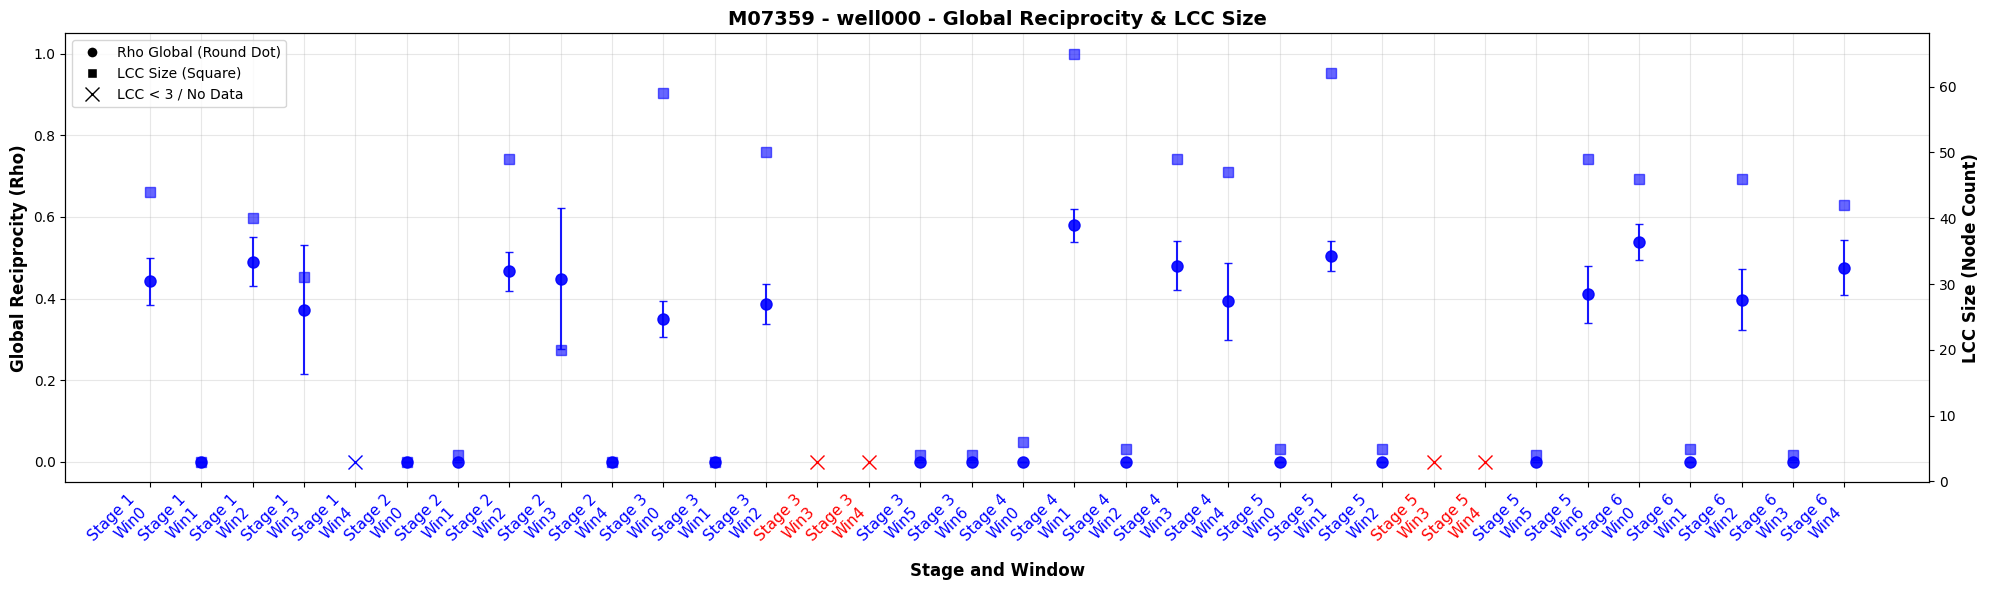

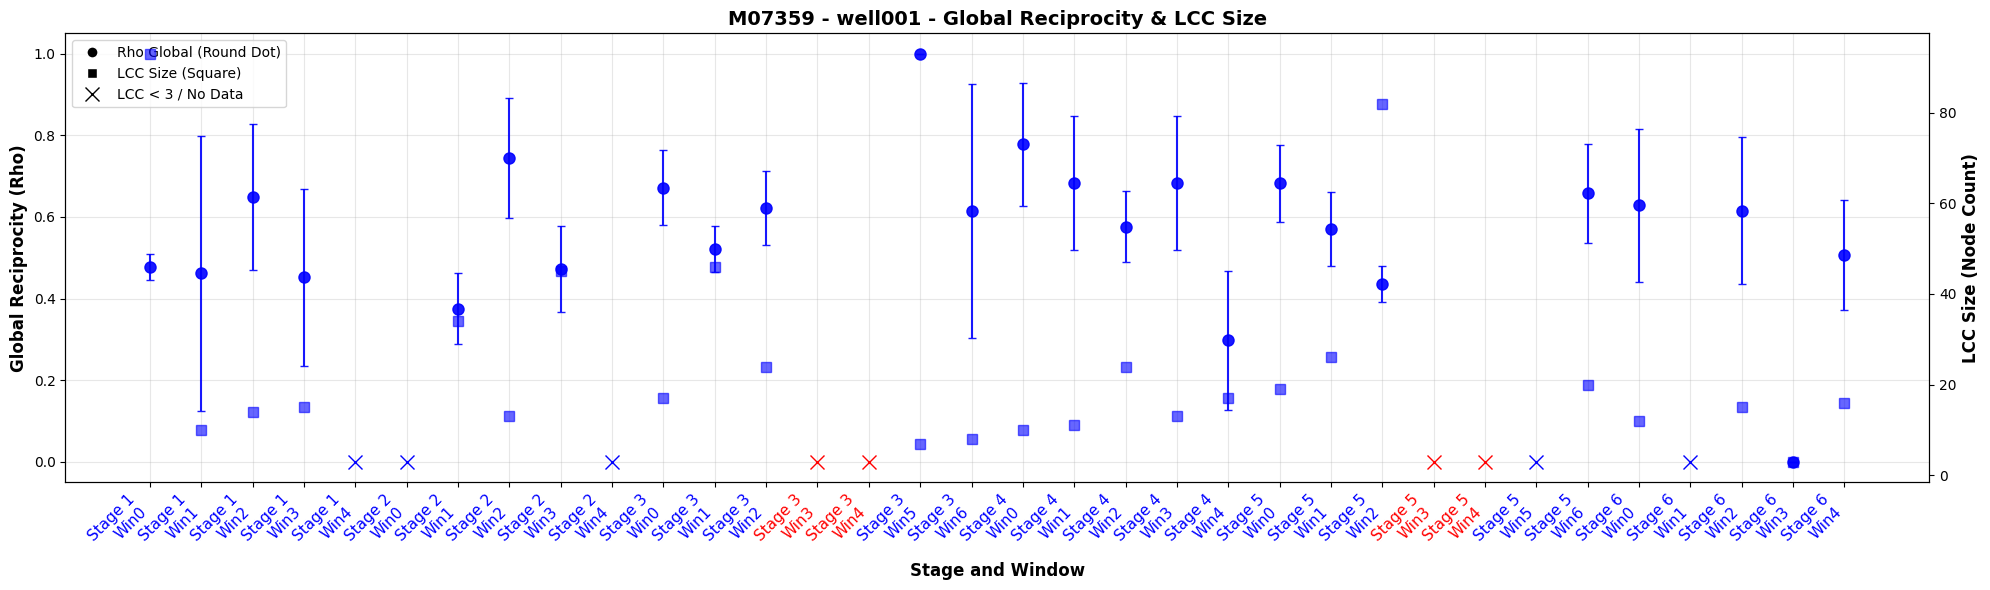

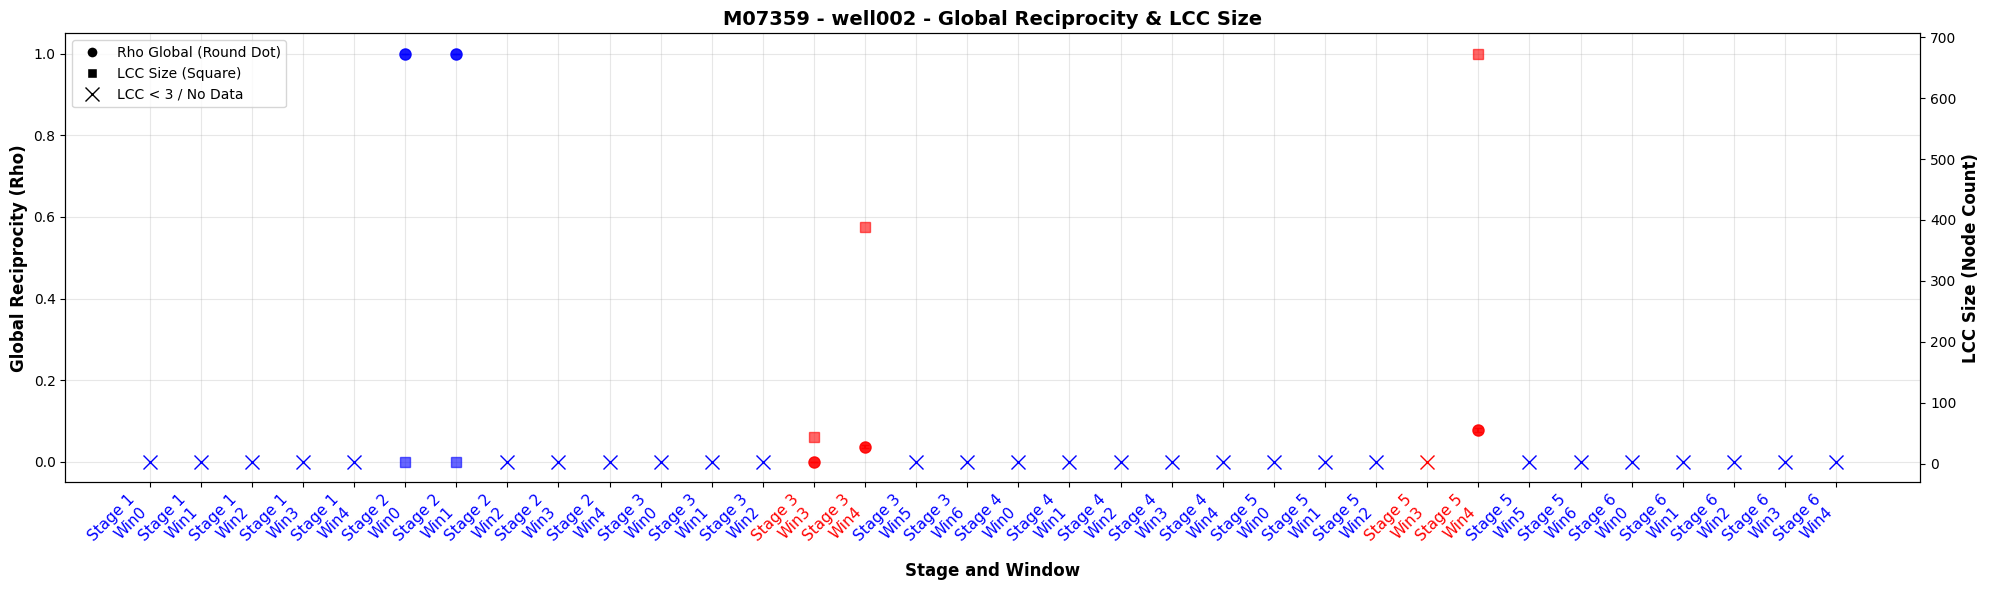

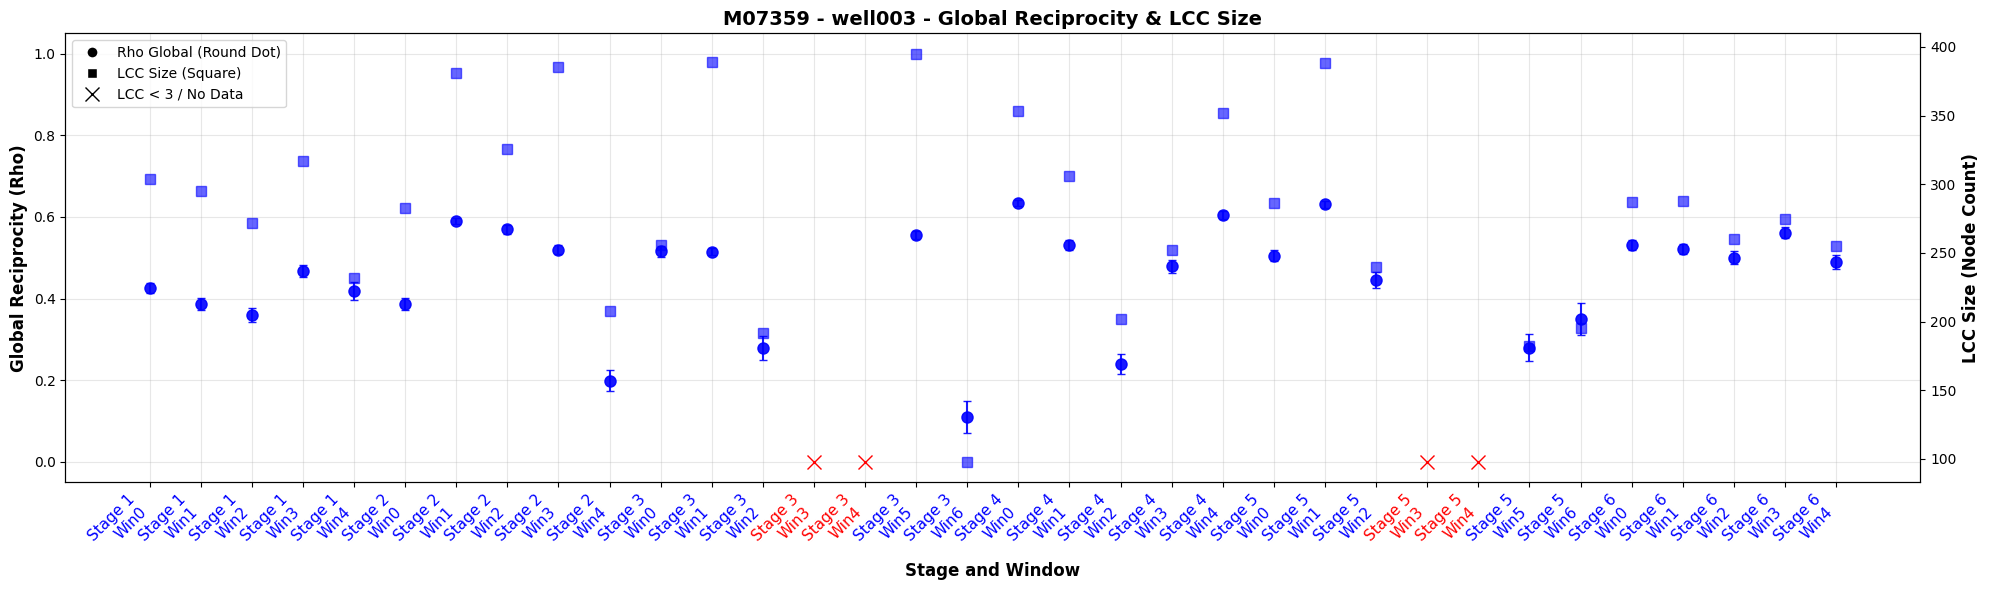

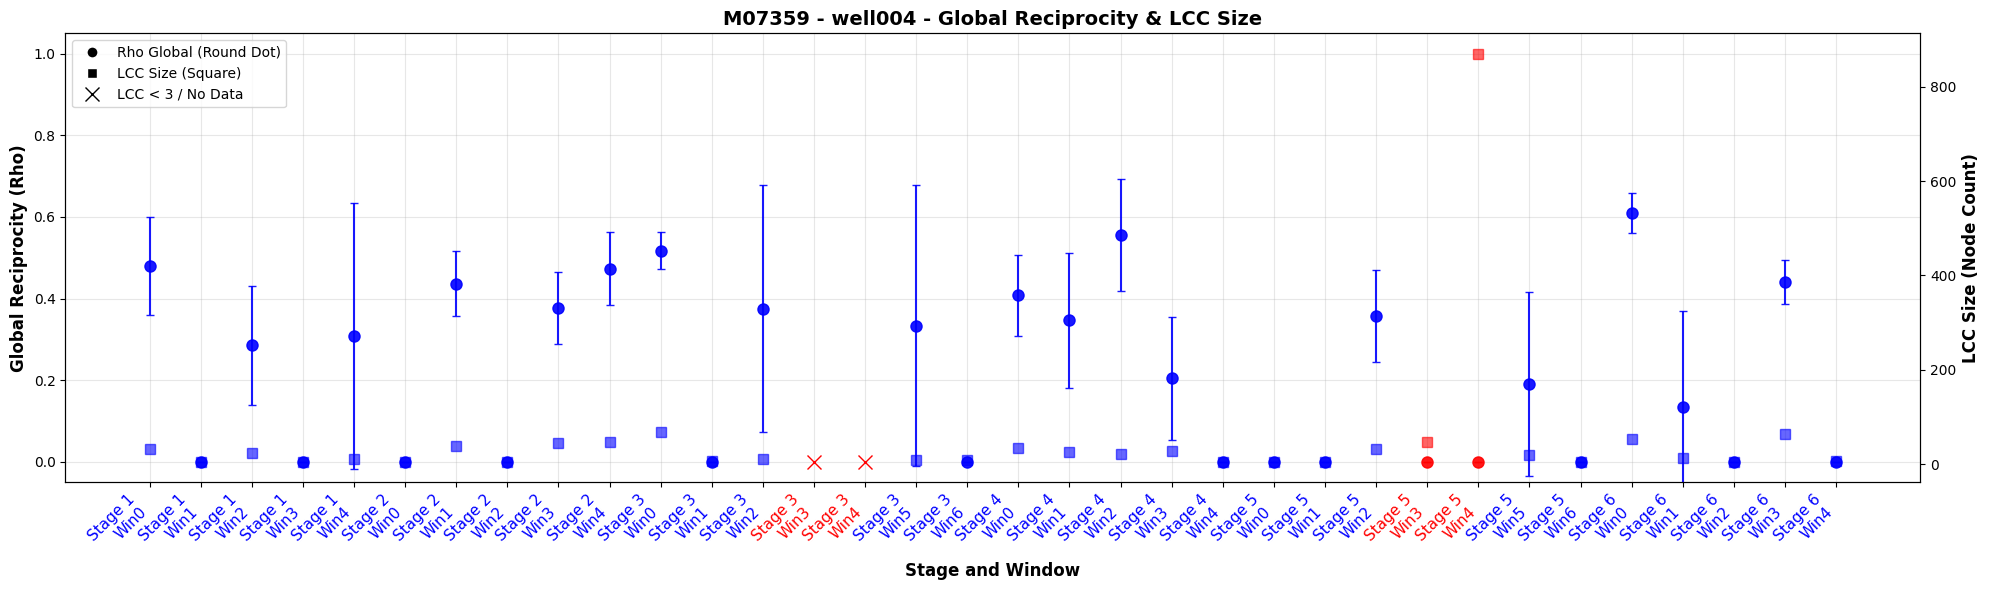

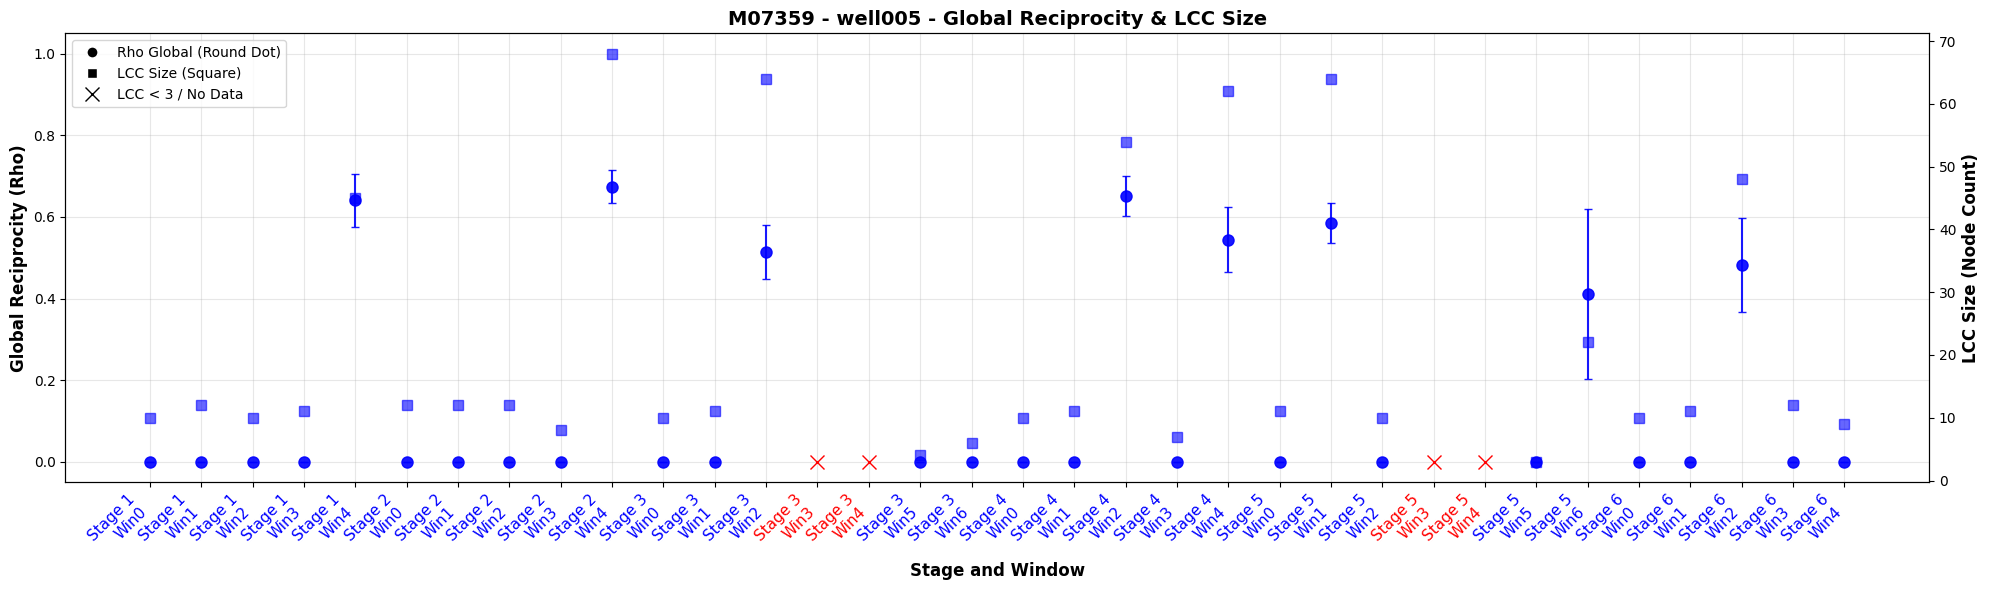

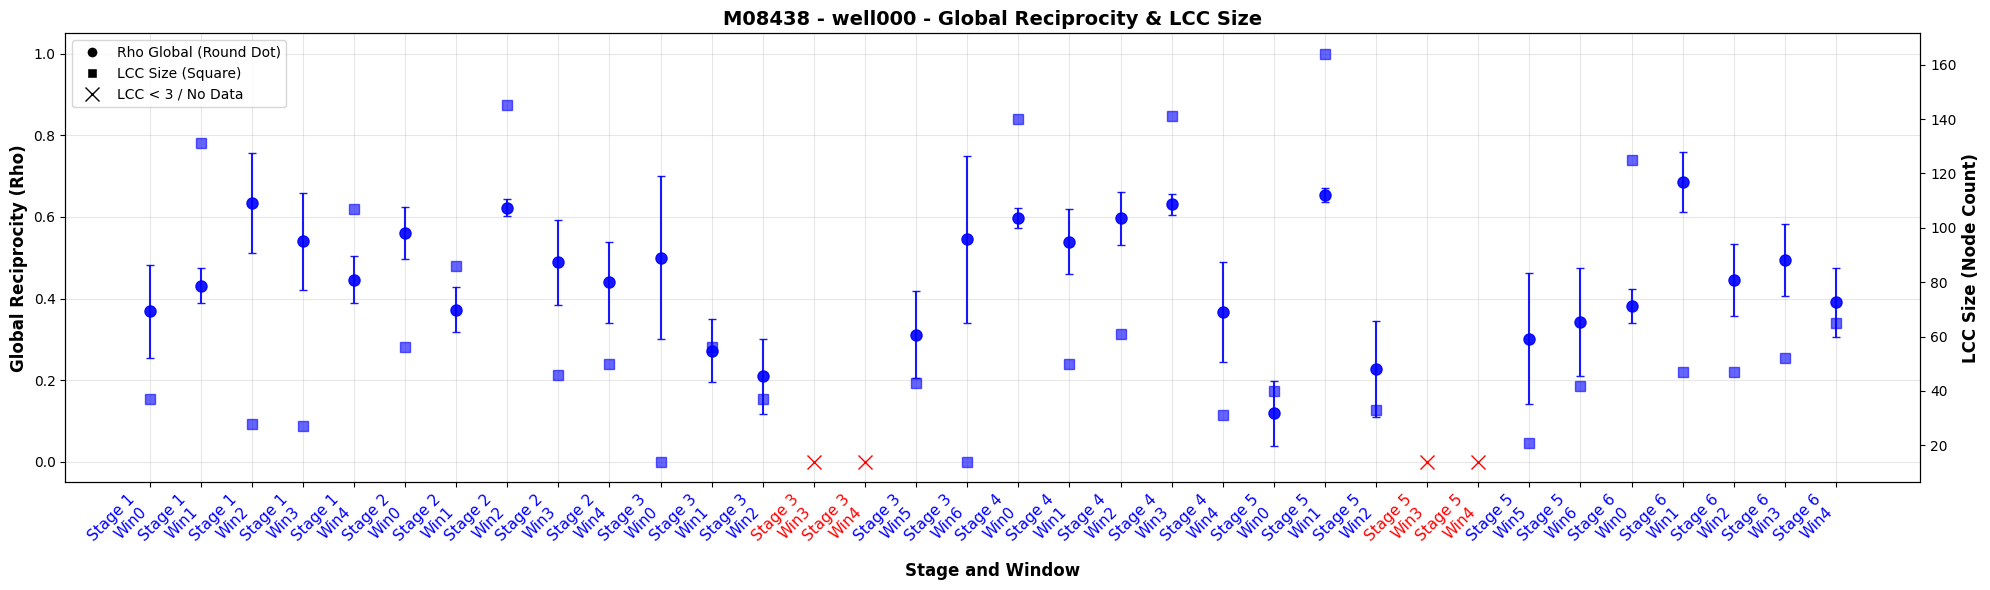

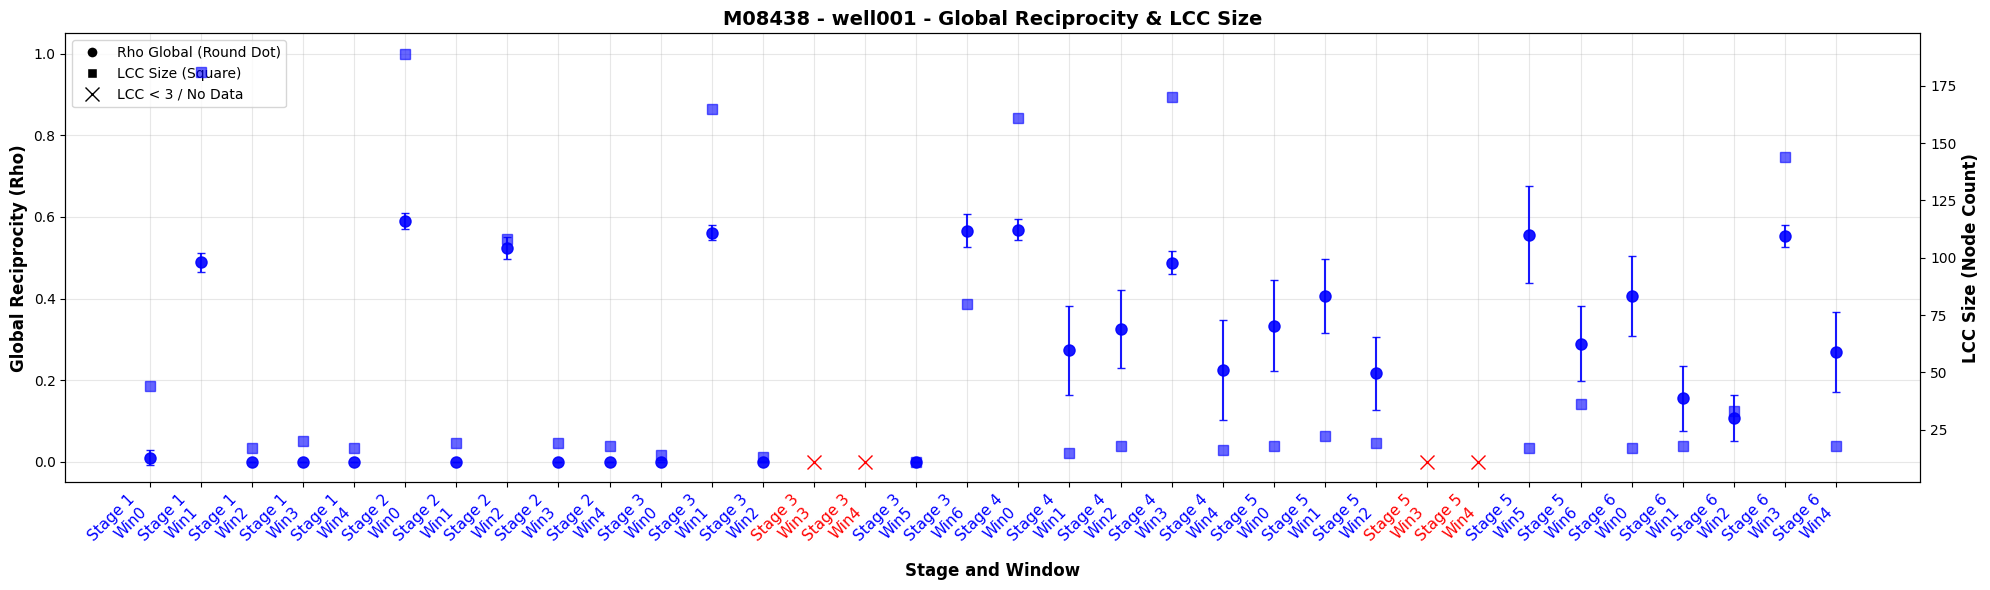

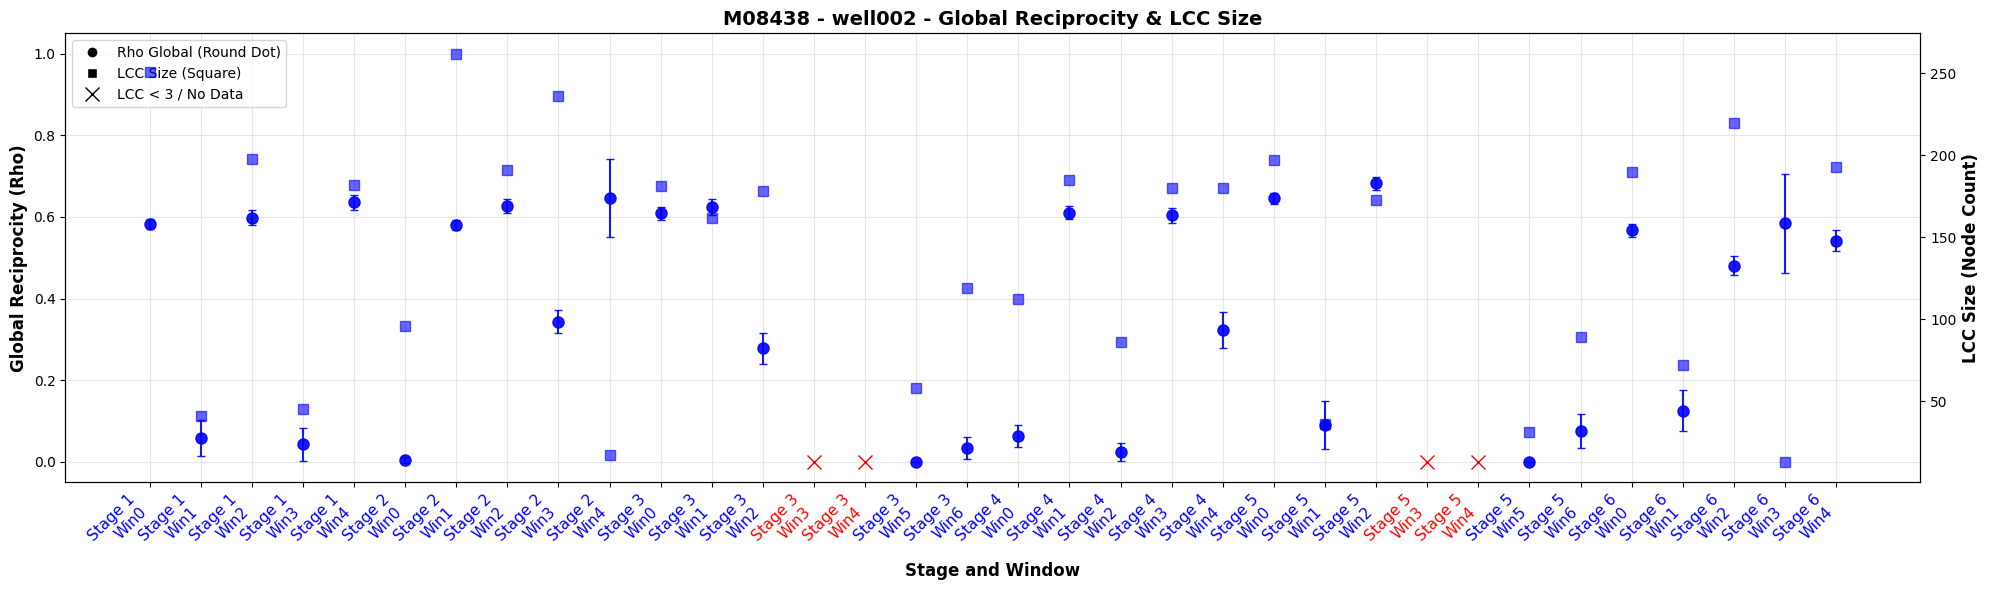

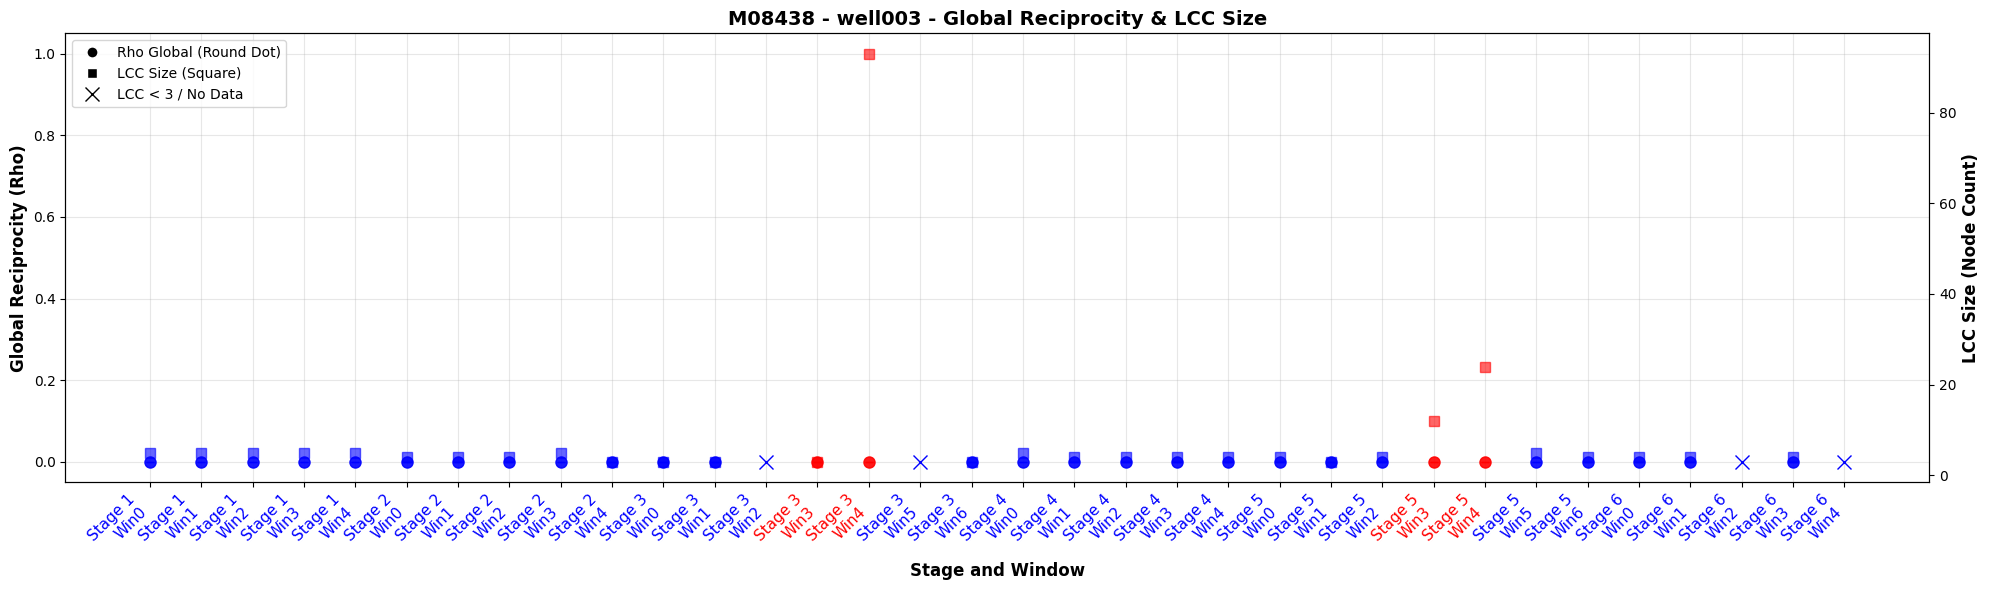

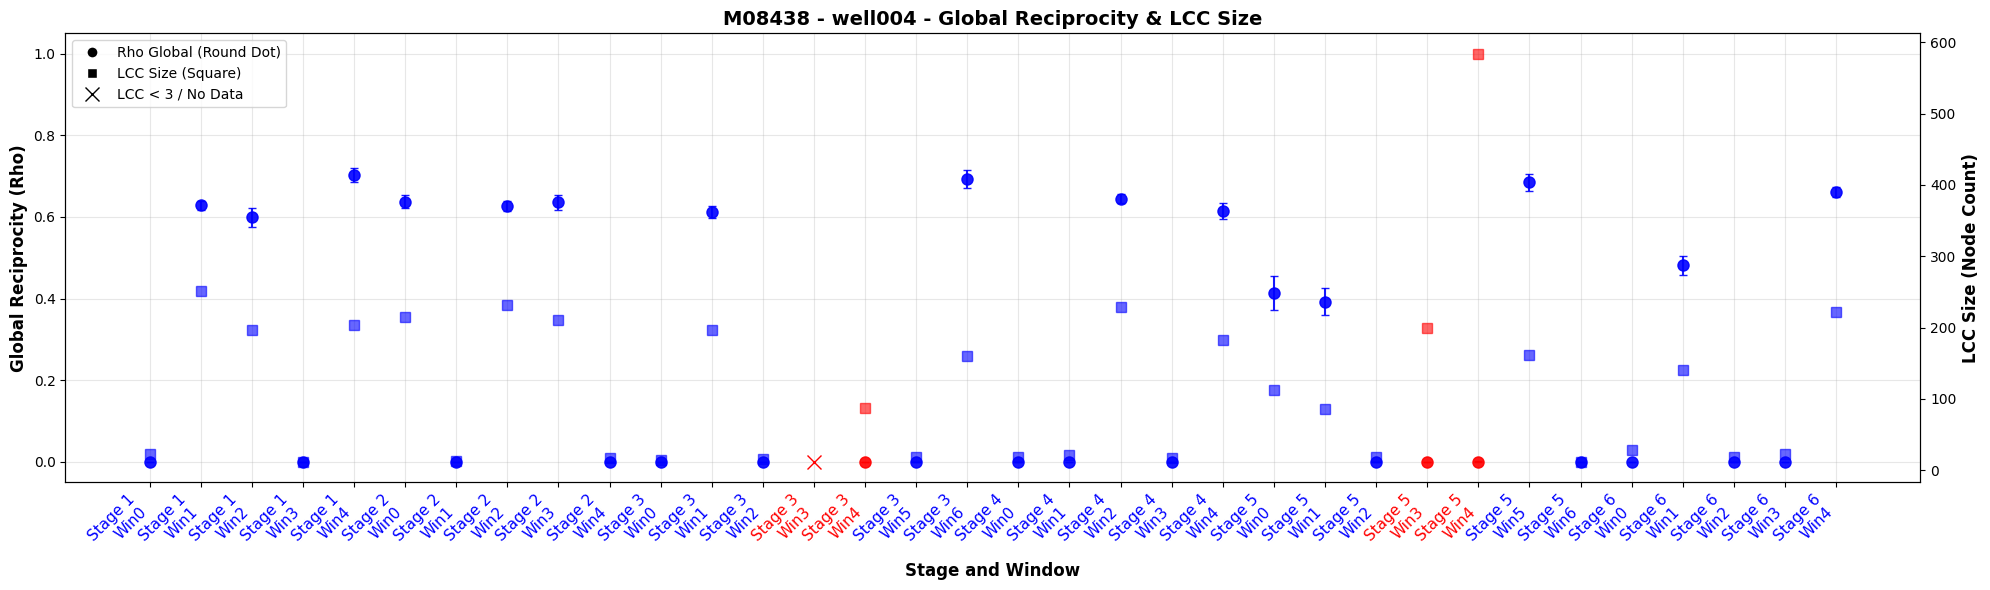

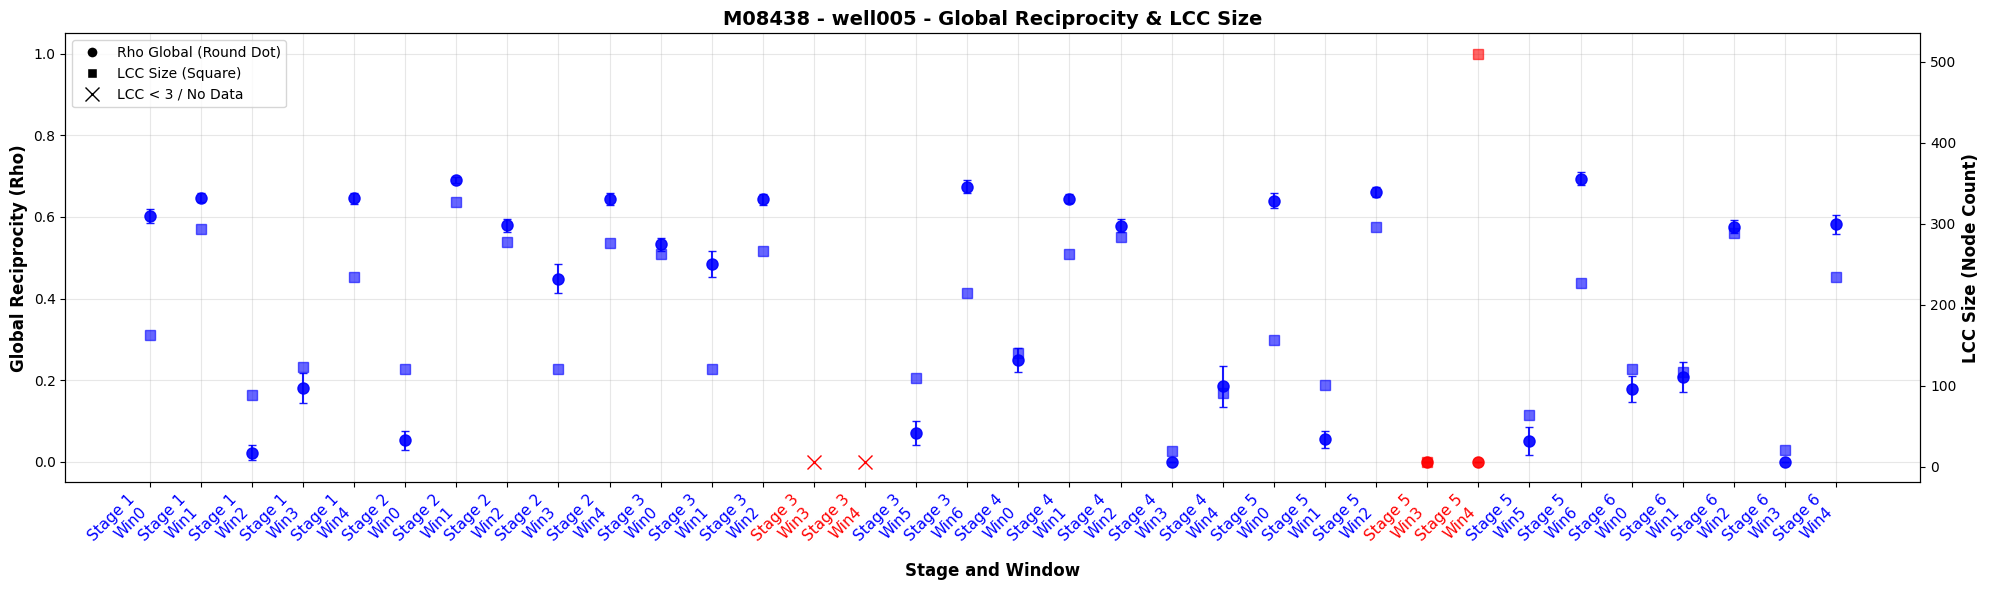


Plotting complete!


In [ ]:


for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, ax = plt.subplots(figsize=(20, 6))
        ax2 = ax.twinx()  # Restore secondary y-axis for LCC size
        
        x_labels = []
        x_positions = []
        label_colors = []
        pos = 0
        
        # Process stages 1 through 6
        for stage_num in range(1, 7):
            stage = f"Stage {stage_num}"
            
            if stage not in results[chip_id][well]:
                continue
            
            stage_data = results[chip_id][well][stage]
            max_win = max(stage_data.keys()) if stage_data else 0
            
            for win_num in range(max_win + 1):
                # Apply skipping logic
                if stage_num in [1, 2, 4, 6] and win_num == 5: continue
                if stage_num in [3, 5] and win_num == 7: continue
                
                x_labels.append(f"{stage}\nWin{win_num}")
                x_positions.append(pos)
                
                # Determine stimulation vs normal
                is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                color = 'red' if is_stim_window else 'blue'
                
                if win_num in stage_data:
                    rho = stage_data[win_num]['rho_global']
                    status = stage_data[win_num]['status']
                    n_directed_edges = stage_data[win_num].get('n_directed_edges', None)
                    n_lcc = stage_data[win_num].get('n_lcc', None)
                    
                    label_colors.append(color) # Color x-axis label
                    
                    if status == 'ok' and rho is not None:
                        # 1. Plot Rho with Error Bar (Round Dot)
                        error_rho = calculate_canonical_rho_error(rho, n_directed_edges)
                        
                        ax.errorbar(pos, rho, yerr=error_rho, fmt='o', markersize=8, 
                                    color=color, ecolor=color, capsize=3, alpha=0.9)
                        
                        # 2. Plot LCC Size (Square) on secondary axis
                        if n_lcc is not None:
                            ax2.plot(pos, n_lcc, 's', markersize=7, color=color, alpha=0.6)
                            
                    else:
                        # Plot Cross for missing/small data
                        ax.plot(pos, 0, 'x', markersize=10, color=color)
                else:
                    # Missing data
                    label_colors.append(color)
                    ax.plot(pos, 0, 'x', markersize=10, color=color)
                
                pos += 1
        
        # --- Formatting ---
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
        
        # Color the x-axis labels (Red for Stim, Blue for Normal)
        for tick_label, c in zip(ax.get_xticklabels(), label_colors):
            tick_label.set_color(c)
        
        # Axis Labels
        ax.set_ylabel('Global Reciprocity (Rho)', fontsize=12, fontweight='bold', color='black')
        ax2.set_ylabel('LCC Size (Node Count)', fontsize=12, fontweight='bold', color='black')
        ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
        
        ax.set_title(f'{chip_id} - {well} - Global Reciprocity & LCC Size', 
                     fontsize=14, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        
        # --- Simplified Legend (Generic) ---
        # Using black color in legend to represent "Any condition"
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=8, label='Rho Global (Round Dot)'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='black', 
                   markersize=7, label='LCC Size (Square)'),
            Line2D([0], [0], marker='x', color='w', markeredgecolor='black', 
                   markersize=10, label='LCC < 3 / No Data'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.show()

print("\nPlotting complete!")

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# --- Configuration ---
output_path = '/cis/home/tchen94/tianyi/Organoid/SOvsMO_may31/rho_global_lcc_size_plots.pdf'

print(f"Starting plot generation. Output will be saved to: {output_path}")

with PdfPages(output_path) as pdf:
    for chip_id in ['M07359', 'M08438']:
        if chip_id not in results:
            continue
        
        wells = sorted(results[chip_id].keys())
        
        for well in wells:
            # Create figure
            fig, ax = plt.subplots(figsize=(20, 6))
            ax2 = ax.twinx()  # Secondary y-axis for LCC size
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip logic
                    if stage_num in [1, 2, 4, 6] and win_num == 5: continue
                    if stage_num in [3, 5] and win_num == 7: continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine color (Red for Stim, Blue for Normal)
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    color = 'red' if is_stim_window else 'blue'
                    label_colors.append(color)
                    
                    if win_num in stage_data:
                        rho = stage_data[win_num].get('rho_global')
                        status = stage_data[win_num].get('status')
                        n_directed_edges = stage_data[win_num].get('n_directed_edges')
                        n_lcc = stage_data[win_num].get('n_lcc')
                        
                        if status == 'ok' and rho is not None:
                            # 1. Plot Rho with Canonical Error Bar (Round Dot)
                            error_rho = calculate_canonical_rho_error(rho, n_directed_edges)
                            
                            ax.errorbar(pos, rho, yerr=error_rho, fmt='o', markersize=8, 
                                        color=color, ecolor=color, capsize=3, alpha=0.9)
                            
                            # 2. Plot LCC Size (Square) on secondary axis
                            if n_lcc is not None:
                                ax2.plot(pos, n_lcc, 's', markersize=7, color=color, alpha=0.6)
                        else:
                            # Missing/Invalid Data (Cross)
                            ax.plot(pos, 0, 'x', markersize=10, color=color)
                    else:
                        # Missing Window (Cross)
                        ax.plot(pos, 0, 'x', markersize=10, color=color)
                    
                    pos += 1
            
            # --- Formatting ---
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
            
            # Color the x-axis labels
            for tick_label, c in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(c)
            
            # Labels and Title
            ax.set_ylabel('Global Reciprocity (Rho)', fontsize=12, fontweight='bold', color='black')
            ax2.set_ylabel('LCC Size (Node Count)', fontsize=12, fontweight='bold', color='black')
            ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
            ax.set_title(f'{chip_id} - {well} - Global Reciprocity & LCC Size', 
                         fontsize=14, fontweight='bold')
            
            # Grid and Limits
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            # Optional: set a reasonable limit for LCC or leave auto-scaled
            # ax2.set_ylim(0, max_lcc_value * 1.1) 
            
            # --- Simplified Legend ---
            # Using 'black' to represent generic shape types
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                       markersize=8, label='Rho Global (Round Dot)'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='black', 
                       markersize=7, label='LCC Size (Square)'),
                Line2D([0], [0], marker='x', color='w', markeredgecolor='black', 
                       markersize=10, label='LCC < 3 / No Data'),
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
            
            plt.tight_layout()
            
            # Save the current figure to the PDF
            pdf.savefig(fig)
            plt.close(fig)  # Close the figure to free memory

print(f"Successfully saved all plots to {output_path}")

Starting plot generation. Output will be saved to: /cis/home/tchen94/tianyi/Organoid/SOvsMO_may31/rho_global_lcc_size_plots.pdf
Successfully saved all plots to /cis/home/tchen94/tianyi/Organoid/SOvsMO_may31/rho_global_lcc_size_plots.pdf


In [ ]:
from matplotlib.lines import Line2D

for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, ax = plt.subplots(figsize=(20, 6))
        ax2 = ax.twinx()  # Create second y-axis for LCC size
        
        x_labels = []
        x_positions = []
        label_colors = []
        pos = 0
        
        # Process stages 1 through 6 (skip Stage 0)
        for stage_num in range(1, 7):
            stage = f"Stage {stage_num}"
            
            if stage not in results[chip_id][well]:
                continue
            
            stage_data = results[chip_id][well][stage]
            max_win = max(stage_data.keys()) if stage_data else 0
            
            for win_num in range(max_win + 1):
                # Skip win 5 for stages 1, 2, 4, 6
                if stage_num in [1, 2, 4, 6] and win_num == 5:
                    continue
                
                # Skip win 7 for stages 3, 5
                if stage_num in [3, 5] and win_num == 7:
                    continue
                
                x_labels.append(f"{stage}\nWin{win_num}")
                x_positions.append(pos)
                
                # Determine if this is a stimulation window
                is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                
                if win_num in stage_data:
                    original_density = stage_data[win_num].get('original_density', None)
                    n_lcc = stage_data[win_num].get('n_lcc', None)
                    status = stage_data[win_num]['status']
                    
                    # Determine color based on stimulation window
                    if is_stim_window:
                        color = 'red'
                        label_colors.append('red')
                    else:
                        color = 'blue'
                        label_colors.append('black')
                    
                    if status == 'ok':
                        # Plot original density with circles
                        if original_density is not None:
                            ax.plot(pos, original_density, 'o', markersize=8, color=color)
                        # Plot LCC Size with squares
                        if n_lcc is not None:
                            ax2.plot(pos, n_lcc, 's', markersize=7, color=color, alpha=0.7)
                    else:
                        # Use cross for missing/invalid data
                        cross_color = 'red' if is_stim_window else 'black'
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                else:
                    # Missing data
                    cross_color = 'red' if is_stim_window else 'black'
                    label_colors.append('red' if is_stim_window else 'black')
                    ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                
                pos += 1
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
        
        # Color the x-axis labels
        for tick_label, color in zip(ax.get_xticklabels(), label_colors):
            tick_label.set_color(color)
        
        ax.set_ylabel('Original Density', fontsize=12, fontweight='bold', color='black')
        ax2.set_ylabel('LCC Size', fontsize=12, fontweight='bold', color='black')
        ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
        ax.set_title(f'{chip_id} - {well} - Original Density and LCC Size across All Stages', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis='y', labelcolor='black')
        ax2.tick_params(axis='y', labelcolor='black')
        
        # Create legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Original Density (Normal)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Original Density (Stim)'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=7, label='LCC Size (Normal)', alpha=0.7),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=7, label='LCC Size (Stim)', alpha=0.7),
            Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.show()

print("\nPlotting complete!")

In [ ]:
chip_id = 'M08438'
well = 'well005'

# Define stimulation stages
stimulation_stages = [ 'Stage 5']

if chip_id in results and well in results[chip_id]:
    print(f"Results for {chip_id} - {well} (Stimulation Stages Only, Win 3 and Win 4):")
    for stage, stage_data in results[chip_id][well].items():
        if stage in stimulation_stages:
            print(f"\nStage: {stage}")
            for win_num in [3, 4]:  # Only consider win 3 and win 4
                if win_num in stage_data:
                    data = stage_data[win_num]
                    original_density = data.get('original_density', None)
                    lcc_size = data.get('n_lcc', None)
                    lcc_density = original_density if lcc_size and lcc_size > 0 else None
                    print(f"  Window {win_num}: Original Density = {original_density}, LCC Size = {lcc_size}, LCC Density = {lcc_density}")
                else:
                    print(f"  Window {win_num}: No data available")
else:
    print(f"No data found for {chip_id} - {well}")

In [ ]:
filename

In [ ]:
filtered_filenames


In [ ]:
# Extract the data for the specified chip, well, stage, and window
stage_data = results.get(chip_id, {}).get(well, {}).get('Stage 5', {})
window_data = stage_data.get(4, {})

if window_data:
    # Load the adjacency matrix for the original graph
    if 'win_3' in preloaded_data[filtered_filenames[0]]['well005']:
        adj = filter_matrix_TC(preloaded_data[filtered_filenames[0]], 'well005', 'win_3')
    else:
        print("Key 'win_4' not found in the data for the specified well.")
        adj = None
    adj_bin = (adj > 0).astype(int)
    
    # Create the original graph
    g = ig.Graph.Adjacency(adj_bin.tolist(), mode="directed")
    
    # Calculate the number of edges and density for the original graph
    num_edges_original = g.ecount()
    density_original = g.density()
    
    # Get the largest connected component (LCC)
    lcc_g = g.components(mode="weak").giant()
    
    # Calculate the number of edges and density for the LCC
    num_edges_lcc = lcc_g.ecount()
    density_lcc = lcc_g.density()
    
    print(f"Original Graph: Number of Edges = {num_edges_original}, Density = {density_original:.4f}")
    print(f"LCC: Number of Edges = {num_edges_lcc}, Density = {density_lcc:.4f}")
else:
    print("No data available for the specified chip, well, stage, and window.")

In [ ]:
preloaded_data[filename][well]

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, ax = plt.subplots(figsize=(20, 6))
        
        x_labels = []
        x_positions = []
        label_colors = []
        pos = 0
        
        # Process stages 1 through 6 (skip Stage 0)
        for stage_num in range(1, 7):
            stage = f"Stage {stage_num}"
            
            if stage not in results[chip_id][well]:
                continue
            
            stage_data = results[chip_id][well][stage]
            max_win = max(stage_data.keys()) if stage_data else 0
            
            for win_num in range(max_win + 1):
                # Skip win 5 for stages 1, 2, 4, 6
                if stage_num in [1, 2, 4, 6] and win_num == 5:
                    continue
                if stage_num in [3, 5] and win_num == 7:
                    continue
                
                x_labels.append(f"{stage}\nWin{win_num}")
                x_positions.append(pos)
                
                # Determine if this is a stimulation window
                is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                
                if win_num in stage_data:
                    rho = stage_data[win_num]['rho_global']
                    status = stage_data[win_num]['status']
                    
                    # Determine color: red for stage 3/5 windows 3/4, blue otherwise
                    if is_stim_window:
                        color = 'red'
                        label_colors.append('red')
                    else:
                        color = 'blue'
                        label_colors.append('black')
                    
                    if status == 'ok' and rho is not None:
                        ax.plot(pos, rho, 'o', markersize=8, color=color)
                    else:
                        # Use red cross for stim windows, black otherwise
                        cross_color = 'red' if is_stim_window else 'black'
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                else:
                    # Missing data
                    cross_color = 'red' if is_stim_window else 'black'
                    label_colors.append('red' if is_stim_window else 'black')
                    ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                
                pos += 1
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        
        # Color the x-axis labels
        for tick_label, color in zip(ax.get_xticklabels(), label_colors):
            tick_label.set_color(color)
        
        ax.set_ylabel('Global Symmetry (Rho Global)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
        ax.set_title(f'{chip_id} - {well} - Global Symmetry across All Stages', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        
        plt.tight_layout()
        plt.show()

print("\nPlotting complete!")

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, ax = plt.subplots(figsize=(20, 6))
        ax2 = ax.twinx()  # Create second y-axis for LCC size
        
        x_labels = []
        x_positions = []
        label_colors = []
        pos = 0
        
        # Process stages 1 through 6 (skip Stage 0)
        for stage_num in range(1, 7):
            stage = f"Stage {stage_num}"
            
            if stage not in results[chip_id][well]:
                continue
            
            stage_data = results[chip_id][well][stage]
            max_win = max(stage_data.keys()) if stage_data else 0
            
            for win_num in range(max_win + 1):
                # Skip win 5 for stages 1, 2, 4, 6
                if stage_num in [1, 2, 4, 6] and win_num == 5:
                    continue
                
                # Skip win 7 for stages 3, 5
                if stage_num in [3, 5] and win_num == 7:
                    continue
                
                x_labels.append(f"{stage}\nWin{win_num}")
                x_positions.append(pos)
                
                # Determine if this is a stimulation window
                is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                
                if win_num in stage_data:
                    rho = stage_data[win_num]['rho_global']
                    cc_dense = stage_data[win_num].get('dens_CC', None)
                    status = stage_data[win_num]['status']
                    n_lcc = stage_data[win_num].get('n_lcc', None)
                    
                    # Determine color based on stimulation window
                    if is_stim_window:
                        color = 'red'
                        label_colors.append('red')
                    else:
                        color = 'blue'
                        label_colors.append('black')
                    
                    if status == 'ok' and rho is not None:
                        # Plot Rho Global with circles
                        ax.plot(pos, rho, 'o', markersize=8, color=color)
                        # Plot LCC Size with squares
                        if n_lcc is not None:
                            ax2.plot(pos, n_lcc, 's', markersize=7, color=color, alpha=0.7)
                        # Plot C -> C Density with green dots
                        if cc_dense is not None:
                            ax.plot(pos, cc_dense, 'o', markersize=6, color='green')
                    else:
                        # Use cross for missing/invalid data
                        cross_color = 'red' if is_stim_window else 'black'
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                else:
                    # Missing data
                    cross_color = 'red' if is_stim_window else 'black'
                    label_colors.append('red' if is_stim_window else 'black')
                    ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                
                pos += 1
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
        
        # Color the x-axis labels
        for tick_label, color in zip(ax.get_xticklabels(), label_colors):
            tick_label.set_color(color)
        
        ax.set_ylabel('Global Symmetry (Rho Global)', fontsize=12, fontweight='bold', color='black')
        ax2.set_ylabel('LCC Size', fontsize=12, fontweight='bold', color='black')
        ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
        ax.set_title(f'{chip_id} - {well} - Global Symmetry, LCC Size, and C -> C Density across All Stages', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis='y', labelcolor='black')
        ax2.tick_params(axis='y', labelcolor='black')
        
        # Create legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Rho Global'),
            #Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Rho Global (Stim)'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=7, label='LCC Size', alpha=0.7),
            #Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=7, label='LCC Size (Stim)', alpha=0.7),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='C -> C Density'),
            Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.show()

print("\nPlotting complete!")

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import os

# Define output path
output_path = '/cis/home/tchen94/tianyi/Organoid/SOvsMO_may31/rho_global_lcc_density_plots.pdf'

# Create PDF file
with PdfPages(output_path) as pdf:
    for chip_id in ['M07359', 'M08438']:
        if chip_id not in results:
            continue
        
        wells = sorted(results[chip_id].keys())
        
        for well in wells:
            fig, ax = plt.subplots(figsize=(20, 6))
            ax2 = ax.twinx()  # Create second y-axis for LCC size
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6 (skip Stage 0)
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip win 5 for stages 1, 2, 4, 6
                    if stage_num in [1, 2, 4, 6] and win_num == 5:
                        continue
                    
                    # Skip win 7 for stages 3, 5
                    if stage_num in [3, 5] and win_num == 7:
                        continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine if this is a stimulation window
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    
                    if win_num in stage_data:
                        rho = stage_data[win_num]['rho_global']
                        cc_dense = stage_data[win_num].get('dens_CC', None)
                        status = stage_data[win_num]['status']
                        n_lcc = stage_data[win_num].get('n_lcc', None)
                        
                        # Determine color based on stimulation window
                        if is_stim_window:
                            color = 'red'
                            label_colors.append('red')
                        else:
                            color = 'blue'
                            label_colors.append('black')
                        
                        if status == 'ok' and rho is not None:
                            # Plot Rho Global with circles
                            ax.plot(pos, rho, 'o', markersize=8, color=color)
                            # Plot LCC Size with squares
                            if n_lcc is not None:
                                ax2.plot(pos, n_lcc, 's', markersize=7, color=color, alpha=0.7)
                            # Plot C -> C Density with green dots
                            if cc_dense is not None:
                                ax.plot(pos, cc_dense, 'o', markersize=6, color='green')
                        else:
                            # Use cross for missing/invalid data
                            cross_color = 'red' if is_stim_window else 'black'
                            ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    else:
                        # Missing data
                        cross_color = 'red' if is_stim_window else 'black'
                        label_colors.append('red' if is_stim_window else 'black')
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    
                    pos += 1
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
            
            # Color the x-axis labels
            for tick_label, color in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(color)
            
            ax.set_ylabel('Global Symmetry (Rho Global)', fontsize=12, fontweight='bold', color='black')
            ax2.set_ylabel('LCC Size', fontsize=12, fontweight='bold', color='black')
            ax.set_xlabel('Stage and Window', fontsize=12, fontweight='bold')
            ax.set_title(f'{chip_id} - {well} - Global Symmetry, LCC Size, and C -> C Density across All Stages', 
                        fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            ax.tick_params(axis='y', labelcolor='black')
            ax2.tick_params(axis='y', labelcolor='black')
            
            # Create legend
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Rho Global'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=7, label='LCC Size', alpha=0.7),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='C -> C Density'),
                Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
            
            plt.tight_layout()
            
            # Save to PDF
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

print(f"\nPlotting complete! Saved to: {output_path}")

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, axes = plt.subplots(2, 2, figsize=(24, 12))
        fig.suptitle(f'{chip_id} - {well} - Densities across All Stages', 
                    fontsize=16, fontweight='bold')
        
        density_keys = ['dens_CC', 'dens_CP', 'dens_PC', 'dens_PP']
        density_labels = ['C -> C Density', 'C -> P Density', 'P -> C Density', 'P -> P Density']
        
        for idx, (dens_key, dens_label) in enumerate(zip(density_keys, density_labels)):
            ax = axes[idx // 2, idx % 2]
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6 (skip Stage 0)
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip win 5 for stages 1, 2, 4, 6
                    if stage_num in [1, 2, 4, 6] and win_num == 5:
                        continue
                    
                    # Skip win 7 for stages 3, 5
                    if stage_num in [3, 5] and win_num == 7:
                        continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine if this is a stimulation window
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    
                    if win_num in stage_data:
                        status = stage_data[win_num]['status']
                        dens_value = stage_data[win_num].get(dens_key, None)
                        
                        # Determine color based on stimulation window
                        if is_stim_window:
                            color = 'red'
                            label_colors.append('red')
                        else:
                            color = 'blue'
                            label_colors.append('black')
                        
                        if status == 'ok' and dens_value is not None:
                            ax.plot(pos, dens_value, 'o', markersize=8, color=color)
                        else:
                            # Use cross for missing/invalid data
                            cross_color = 'red' if is_stim_window else 'black'
                            ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    else:
                        # Missing data
                        cross_color = 'red' if is_stim_window else 'black'
                        label_colors.append('red' if is_stim_window else 'black')
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    
                    pos += 1
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
            
            # Color the x-axis labels
            for tick_label, color in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(color)
            
            ax.set_ylabel(dens_label, fontsize=11, fontweight='bold')
            ax.set_xlabel('Stage and Window', fontsize=11, fontweight='bold')
            ax.set_title(dens_label, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            
            # Create legend (only on first subplot)
            if idx == 0:
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Stim'),
                    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
        
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

print("\nPlotting complete!")

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, axes = plt.subplots(2, 2, figsize=(24, 12))
        fig.suptitle(f'{chip_id} - {well} - Undirected Densities across All Stages', 
                    fontsize=16, fontweight='bold')
        
        density_keys = ['dens_CC_undirected', 'dens_CP_undirected', 'dens_PP_undirected']
        density_labels = ['undirected C -> C Density', 'undirected C -> P Density', 'undirected P -> P Density']
        
        for idx, (dens_key, dens_label) in enumerate(zip(density_keys, density_labels)):
            ax = axes[idx // 2, idx % 2]
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6 (skip Stage 0)
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip win 5 for stages 1, 2, 4, 6
                    if stage_num in [1, 2, 4, 6] and win_num == 5:
                        continue
                    
                    # Skip win 7 for stages 3, 5
                    if stage_num in [3, 5] and win_num == 7:
                        continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine if this is a stimulation window
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    
                    if win_num in stage_data:
                        status = stage_data[win_num]['status']
                        dens_value = stage_data[win_num].get(dens_key, None)
                        n_core = stage_data[win_num].get('n_core_undirected', None)
                        n_periph = stage_data[win_num].get('n_periph_undirected', None)
                        
                        # Determine color based on stimulation window
                        if is_stim_window:
                            color = 'red'
                            label_colors.append('red')
                        else:
                            color = 'blue'
                            label_colors.append('black')
                        
                        if status == 'ok' and dens_value is not None:
                            # Calculate error bar
                            if dens_key == 'dens_CC_undirected' and n_core is not None and n_core > 1:
                                n_edges = n_core * (n_core - 1) / 2
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            elif dens_key == 'dens_PP_undirected' and n_periph is not None and n_periph > 1:
                                n_edges = n_periph * (n_periph - 1) / 2
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            elif dens_key == 'dens_CP_undirected' and n_core is not None and n_periph is not None:
                                n_edges = n_core * n_periph
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            else:
                                error = 0
                            
                            ax.errorbar(pos, dens_value, yerr=error, fmt='o', markersize=8, 
                                       color=color, ecolor=color, capsize=3, alpha=0.7)
                        else:
                            # Use cross for missing/invalid data
                            cross_color = 'red' if is_stim_window else 'black'
                            ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    else:
                        # Missing data
                        cross_color = 'red' if is_stim_window else 'black'
                        label_colors.append('red' if is_stim_window else 'black')
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    
                    pos += 1
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
            
            # Color the x-axis labels
            for tick_label, color in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(color)
            
            ax.set_ylabel(dens_label, fontsize=11, fontweight='bold')
            ax.set_xlabel('Stage and Window', fontsize=11, fontweight='bold')
            ax.set_title(dens_label, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            
            # Create legend (only on first subplot)
            if idx == 0:
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Stim'),
                    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
        
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

print("\nPlotting complete!")

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, axes = plt.subplots(2, 2, figsize=(24, 12))
        fig.suptitle(f'{chip_id} - {well} - Undirected Densities across All Stages', 
                    fontsize=16, fontweight='bold')
        
        density_keys = ['dens_CC_undirected', 'dens_CP_undirected', 'dens_PP_undirected']
        density_labels = ['undirected C -> C Density', 'undirected C -> P Density', 'undirected P -> P Density']
        
        for idx, (dens_key, dens_label) in enumerate(zip(density_keys, density_labels)):
            ax = axes[idx // 2, idx % 2]
            ax2 = ax.twinx()  # Create second y-axis for n_core
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6 (skip Stage 0)
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip win 5 for stages 1, 2, 4, 6
                    if stage_num in [1, 2, 4, 6] and win_num == 5:
                        continue
                    
                    # Skip win 7 for stages 3, 5
                    if stage_num in [3, 5] and win_num == 7:
                        continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine if this is a stimulation window
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    
                    if win_num in stage_data:
                        status = stage_data[win_num]['status']
                        dens_value = stage_data[win_num].get(dens_key, None)
                        n_core = stage_data[win_num].get('n_core_undirected', None)
                        n_periph = stage_data[win_num].get('n_periph_undirected', None)
                        
                        # Determine color based on stimulation window
                        if is_stim_window:
                            color = 'red'
                            label_colors.append('red')
                        else:
                            color = 'blue'
                            label_colors.append('black')
                        
                        if status == 'ok' and dens_value is not None:
                            # Calculate error bar
                            if dens_key == 'dens_CC_undirected' and n_core is not None and n_core > 1:
                                n_edges = n_core * (n_core - 1) / 2
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            elif dens_key == 'dens_PP_undirected' and n_periph is not None and n_periph > 1:
                                n_edges = n_periph * (n_periph - 1) / 2
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            elif dens_key == 'dens_CP_undirected' and n_core is not None and n_periph is not None:
                                n_edges = n_core * n_periph
                                se = np.sqrt(dens_value * (1 - dens_value) / n_edges) if n_edges > 0 else 0
                                error = 1.96 * se
                            else:
                                error = 0
                            
                            ax.errorbar(pos, dens_value, yerr=error, fmt='o', markersize=8, 
                                       color=color, ecolor=color, capsize=3, alpha=0.7)
                            
                            # Plot n_core as green squares on secondary y-axis
                            if n_core is not None:
                                ax2.plot(pos, n_core, 's', markersize=6, color='green', alpha=0.7)
                        else:
                            # Use cross for missing/invalid data
                            cross_color = 'red' if is_stim_window else 'black'
                            ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    else:
                        # Missing data
                        cross_color = 'red' if is_stim_window else 'black'
                        label_colors.append('red' if is_stim_window else 'black')
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    
                    pos += 1
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
            
            # Color the x-axis labels
            for tick_label, color in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(color)
            
            ax.set_ylabel(dens_label, fontsize=11, fontweight='bold')
            ax2.set_ylabel('n_core (undirected)', fontsize=11, fontweight='bold', color='green')
            ax.set_xlabel('Stage and Window', fontsize=11, fontweight='bold')
            ax.set_title(dens_label, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            ax2.tick_params(axis='y', labelcolor='green')
            
            # Create legend (only on first subplot)
            if idx == 0:
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Density (Normal)'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Density (Stim)'),
                    Line2D([0], [0], marker='s', color='w', markerfacecolor='green', markersize=6, label='n_core', alpha=0.7),
                    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
        
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

print("\nPlotting complete!")

In [ ]:
for chip_id in ['M07359', 'M08438']:
    if chip_id not in results:
        continue
    
    wells = sorted(results[chip_id].keys())
    
    for well in wells:
        fig, axes = plt.subplots(1, 2, figsize=(24, 6))
        fig.suptitle(f'{chip_id} - {well} - Core and LCC Ratios across All Stages', 
                    fontsize=16, fontweight='bold')
        
        ratio_keys = ['core_lcc_ratio', 'lcc_original_ratio']
        ratio_labels = ['n_core / n_lcc (undirected)', 'n_lcc / n_original']
        
        for idx, (ratio_key, ratio_label) in enumerate(zip(ratio_keys, ratio_labels)):
            ax = axes[idx]
            
            x_labels = []
            x_positions = []
            label_colors = []
            pos = 0
            
            # Process stages 1 through 6 (skip Stage 0)
            for stage_num in range(1, 7):
                stage = f"Stage {stage_num}"
                
                if stage not in results[chip_id][well]:
                    continue
                
                stage_data = results[chip_id][well][stage]
                max_win = max(stage_data.keys()) if stage_data else 0
                
                for win_num in range(max_win + 1):
                    # Skip win 5 for stages 1, 2, 4, 6
                    if stage_num in [1, 2, 4, 6] and win_num == 5:
                        continue
                    
                    # Skip win 7 for stages 3, 5
                    if stage_num in [3, 5] and win_num == 7:
                        continue
                    
                    x_labels.append(f"{stage}\nWin{win_num}")
                    x_positions.append(pos)
                    
                    # Determine if this is a stimulation window
                    is_stim_window = stage_num in [3, 5] and win_num in [3, 4]
                    
                    if win_num in stage_data:
                        status = stage_data[win_num]['status']
                        n_core = stage_data[win_num].get('n_core_undirected', None)
                        n_lcc = stage_data[win_num].get('n_lcc', None)
                        n_original = stage_data[win_num].get('n_original', None)
                        
                        # Calculate ratio
                        ratio_value = None
                        if ratio_key == 'core_lcc_ratio':
                            if n_core is not None and n_lcc is not None and n_lcc > 0:
                                ratio_value = n_core / n_lcc
                        elif ratio_key == 'lcc_original_ratio':
                            if n_lcc is not None and n_original is not None and n_original > 0:
                                ratio_value = n_lcc / n_original
                        
                        # Determine color based on stimulation window
                        if is_stim_window:
                            color = 'red'
                            label_colors.append('red')
                        else:
                            color = 'blue'
                            label_colors.append('black')
                        
                        if status == 'ok' and ratio_value is not None:
                            ax.plot(pos, ratio_value, 'o', markersize=8, color=color)
                        else:
                            # Use cross for missing/invalid data
                            cross_color = 'red' if is_stim_window else 'black'
                            ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    else:
                        # Missing data
                        cross_color = 'red' if is_stim_window else 'black'
                        label_colors.append('red' if is_stim_window else 'black')
                        ax.plot(pos, 0, 'x', markersize=10, color=cross_color)
                    
                    pos += 1
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
            
            # Color the x-axis labels
            for tick_label, color in zip(ax.get_xticklabels(), label_colors):
                tick_label.set_color(color)
            
            ax.set_ylabel(ratio_label, fontsize=11, fontweight='bold')
            ax.set_xlabel('Stage and Window', fontsize=11, fontweight='bold')
            ax.set_title(ratio_label, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            
            # Create legend (only on first subplot)
            if idx == 0:
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Stim'),
                    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, label='No Data/LCC<11'),
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

print("\nPlotting complete!")